# Credit Card Fraud Detection
## Individual Report — Personal Contribution
### Hybrid Model: Autoencoder + Random Forest
---
**Author:** Alban Plakalliu  
**Dataset:** Credit Card Fraud Detection (Kaggle — MLG-ULB)  
**Model:** Semi-Supervised Hybrid (Autoencoder Anomaly Scoring + Random Forest Classifier)

---
## Section 1 — Data Analysis & Exploratory Data Analysis (EDA)

### 1.1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


### 1.2 Load Dataset

In [18]:
df = pd.read_excel('/content/creditcard_1.xlsx', engine='openpyxl')
print('Dataset loaded successfully.')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1.3 Dataset Overview

In [19]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

### 1.4 Missing Values & Duplicates

In [20]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal duplicate rows: {df.duplicated().sum()}')

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total duplicate rows: 1081


### 1.5 Descriptive Statistics

In [21]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,...,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 1.6 Class Distribution — Fraud vs Legitimate

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


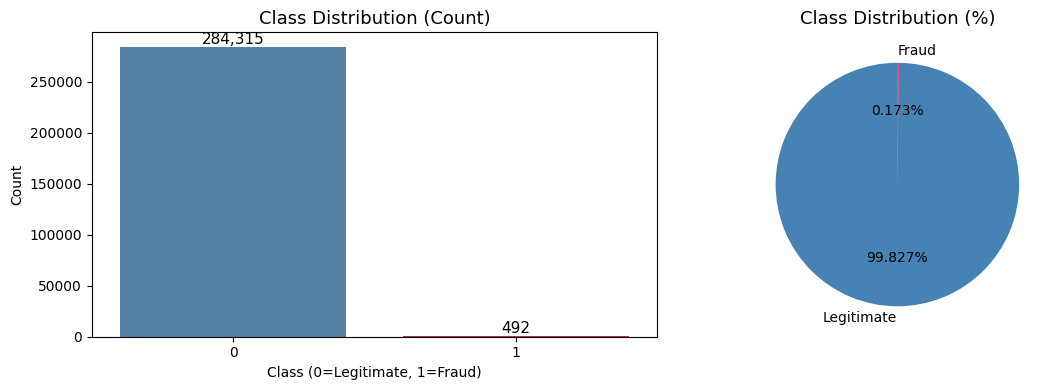

In [22]:
target = 'Class'
print('Class Distribution:')
print(df[target].value_counts())
print(f'\nFraud percentage: {df[target].mean()*100:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=df[target], ax=axes[0], palette=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)
df[target].value_counts().plot.pie(ax=axes[1], labels=['Legitimate', 'Fraud'],
    autopct='%1.3f%%', colors=['steelblue', 'crimson'], startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=13)
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7 Transaction Amount & Time Distributions

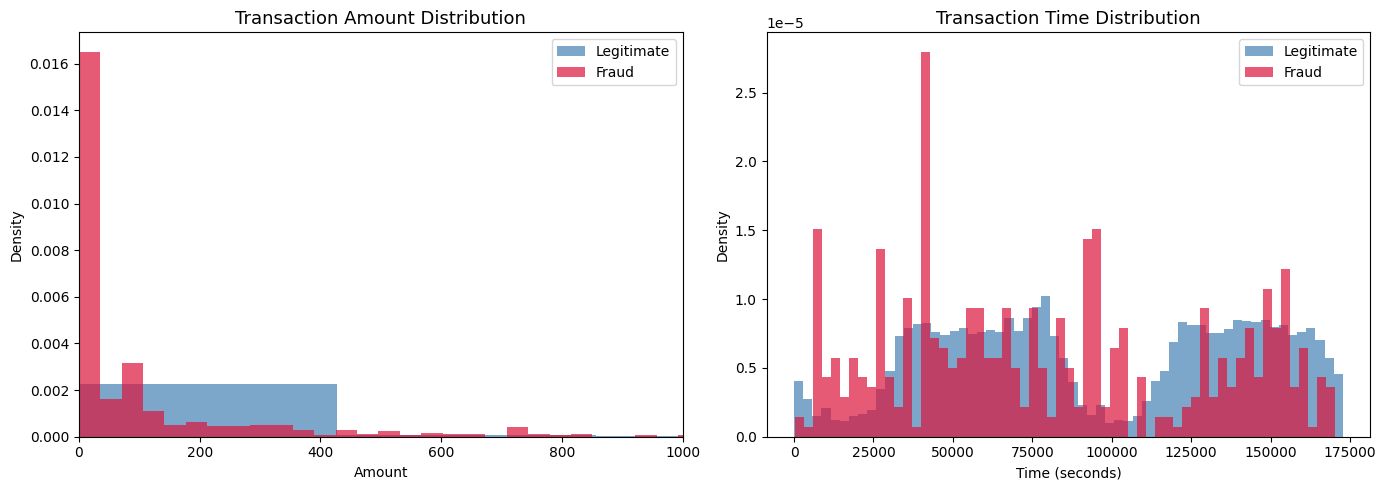

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.7, color='steelblue', label='Legitimate', density=True)
axes[0].hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.7, color='crimson', label='Fraud', density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=13)
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, 1000)
axes[1].hist(df[df['Class']==0]['Time'], bins=60, alpha=0.7, color='steelblue', label='Legitimate', density=True)
axes[1].hist(df[df['Class']==1]['Time'], bins=60, alpha=0.7, color='crimson', label='Fraud', density=True)
axes[1].set_title('Transaction Time Distribution', fontsize=13)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Density')
axes[1].legend()
plt.tight_layout()
plt.savefig('amount_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 Boxplots — Fraud vs Legitimate

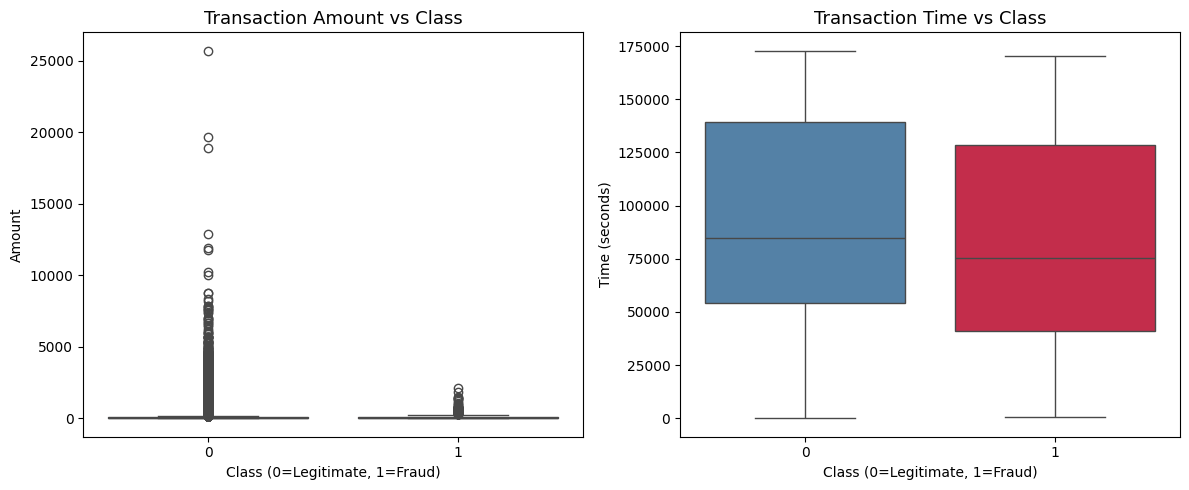

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0], palette=['steelblue', 'crimson'])
axes[0].set_title('Transaction Amount vs Class', fontsize=13)
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Amount')
sns.boxplot(x='Class', y='Time', data=df, ax=axes[1], palette=['steelblue', 'crimson'])
axes[1].set_title('Transaction Time vs Class', fontsize=13)
axes[1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[1].set_ylabel('Time (seconds)')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.9 Correlation Heatmap

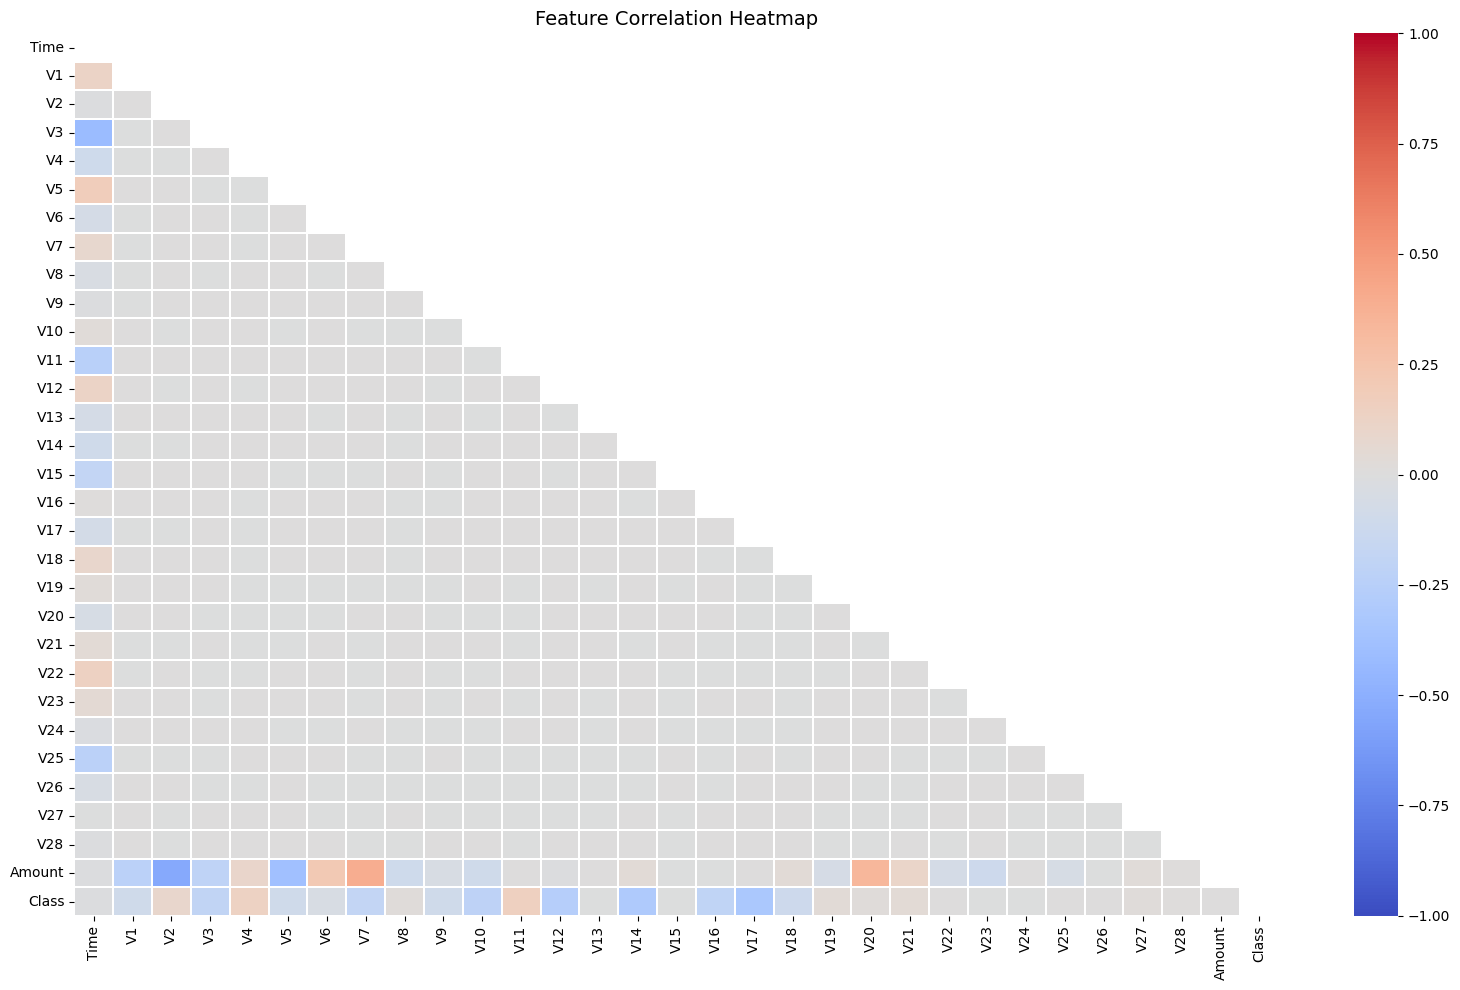

In [25]:
plt.figure(figsize=(16, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm',
            linewidths=0.3, annot=False, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.10 Top Features Correlated with Fraud Class

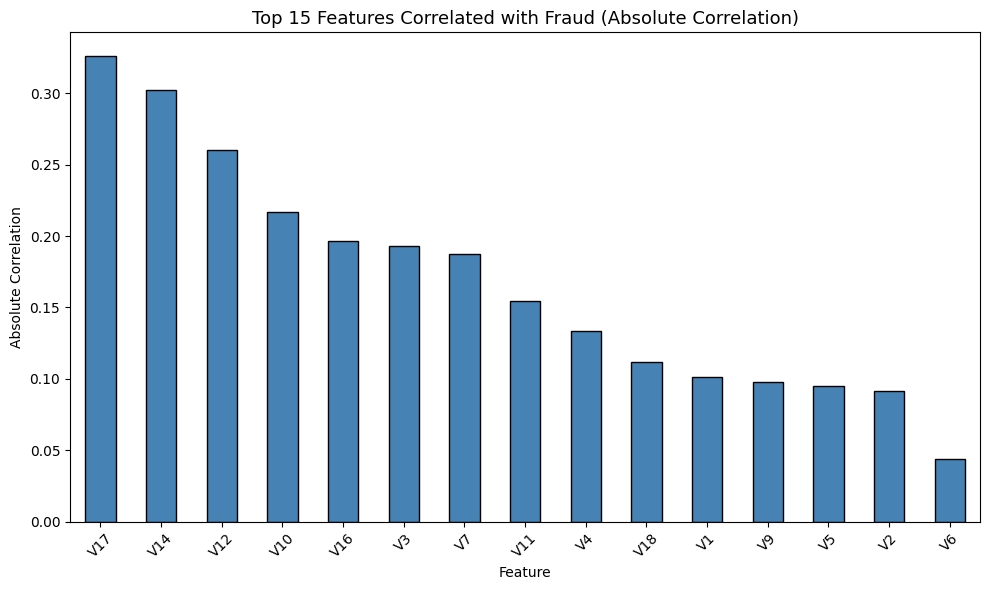

Top 10 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [26]:
fraud_corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fraud_corr.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Correlated with Fraud (Absolute Correlation)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_features_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 10 features correlated with fraud:')
print(fraud_corr.head(10))

---
## Section 2 — Hybrid Model: Autoencoder + Random Forest
> **Personal Contribution** — Semi-supervised hybrid combining unsupervised anomaly detection (Autoencoder) with supervised classification (Random Forest).

### 2.1 Import Libraries for Hybrid Pipeline

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
import time
print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully.')

TensorFlow version: 2.20.0
All libraries imported successfully.


### 2.2 Define Features and Target

In [28]:
target = 'Class'
X = df.drop(columns=[target])
y = df[target]
print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (284807, 30)
Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


### 2.3 Dedicated Train-Test Split for AE-RF Pipeline

In [29]:
X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('Dedicated AE-RF split created.')
print(f'AE Train: {X_train_ae.shape} | AE Test: {X_test_ae.shape}')
print(f'\nClass distribution (AE Train):\n{y_train_ae.value_counts()}')

Dedicated AE-RF split created.
AE Train: (227845, 30) | AE Test: (56962, 30)

Class distribution (AE Train):
Class
0    227451
1       394
Name: count, dtype: int64


### 2.4 Feature Scaling — StandardScaler
> StandardScaler is used here instead of RobustScaler because Autoencoders require zero-mean, unit-variance input for stable gradient-based training. A dedicated scaler instance prevents data leakage between pipelines.

In [30]:
scaler_ae = StandardScaler()
X_train_scaled_ae = scaler_ae.fit_transform(X_train_ae)
X_test_scaled_ae  = scaler_ae.transform(X_test_ae)
print('StandardScaler fitted on AE training data only.')
print(f'Scaled train shape: {X_train_scaled_ae.shape}')
print(f'Scaled test shape:  {X_test_scaled_ae.shape}')

StandardScaler fitted on AE training data only.
Scaled train shape: (227845, 30)
Scaled test shape:  (56962, 30)


### 2.5 Autoencoder Architecture

In [31]:
def create_autoencoder(input_dim):

    '''
    Improved Autoencoder for latent feature extraction.
    Architecture:
    Input -> 64 -> 32 -> 16(latent) -> 32 -> 64 -> Output
    '''

    input_layer = Input(shape=(input_dim,), name='input_layer')

    # ================= ENCODER =================
    x = Dense(64, activation='relu')(input_layer)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = Dense(32, activation='relu')(x)

    latent = Dense(16, activation='relu', name='latent')(x)

    # ================= DECODER =================
    x = Dense(32, activation='relu')(latent)

    x = Dense(64, activation='relu')(x)

    output_layer = Dense(input_dim, activation='linear')(x)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )

    return autoencoder


autoencoder = create_autoencoder(X_train_scaled_ae.shape[1])

autoencoder.summary()


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 7)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 15)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 30)             │           480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177 (4.60 KB)

 Trainable params: 1,177 (4.60 KB)

 Non-trainable params: 0 (0.00 B)

### 2.6 Train Autoencoder (50 Epochs)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print('Training Improved Autoencoder...')

history = autoencoder.fit(
    X_train_scaled_ae,
    X_train_scaled_ae,
    epochs=35,
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print('\nImproved Autoencoder training complete.')


Training Autoencoder...
Epoch 1/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7980 - val_loss: 0.6592
Epoch 2/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6300 - val_loss: 0.5772
Epoch 3/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5631 - val_loss: 0.5279
Epoch 4/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5216 - val_loss: 0.5060
Epoch 5/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5059 - val_loss: 0.4975
Epoch 6/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4973 - val_loss: 0.4911
Epoch 7/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4916 - val_loss: 0.4881
Epoch 8/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4882 - val_loss: 0.4850
Epoch 9/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4850 - val_loss: 0.4822
Epoch 10/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4820 - val_loss: 0.4796
Epoch 11/50
802/802 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4797 - val_loss: 0.4782
Epoch 12/50
802/802 ━━━━━━━━

### 2.7 Training Loss Curve

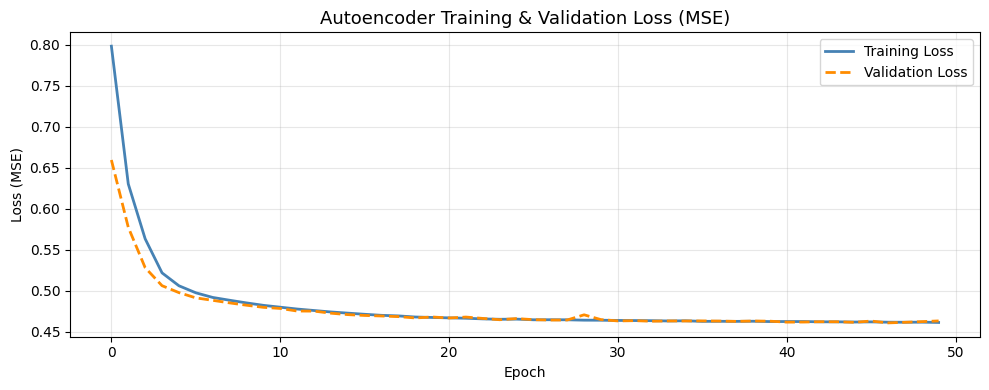

Final Training Loss:   0.461136
Final Validation Loss: 0.463007


In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
plt.title('Autoencoder Training & Validation Loss (MSE)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final Training Loss:   {history.history["loss"][-1]:.6f}')
print(f'Final Validation Loss: {history.history["val_loss"][-1]:.6f}')

### 2.8 Compute Reconstruction Error (Anomaly Score)

In [34]:
# ==========================================================
# LATENT FEATURE EXTRACTION
# ==========================================================

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer('latent').output
)

X_train_encoded = encoder.predict(X_train_scaled_ae, verbose=0)
X_test_encoded  = encoder.predict(X_test_scaled_ae, verbose=0)

print('Encoded Train Shape:', X_train_encoded.shape)
print('Encoded Test Shape :', X_test_encoded.shape)

# ==========================================================
# RECONSTRUCTION ERROR
# ==========================================================

reconstructions_train = autoencoder.predict(X_train_scaled_ae, verbose=0)
reconstructions_test  = autoencoder.predict(X_test_scaled_ae, verbose=0)

mse_train = np.mean(np.power(X_train_scaled_ae - reconstructions_train, 2), axis=1)
mse_test  = np.mean(np.power(X_test_scaled_ae  - reconstructions_test, 2), axis=1)

print('\nReconstruction error generated successfully.')


Train anomaly score — mean: 0.462818 | max: 195.8599
Test  anomaly score — mean: 0.465821  | max: 87.3987


### 2.9 Anomaly Score Distribution — Fraud vs Legitimate

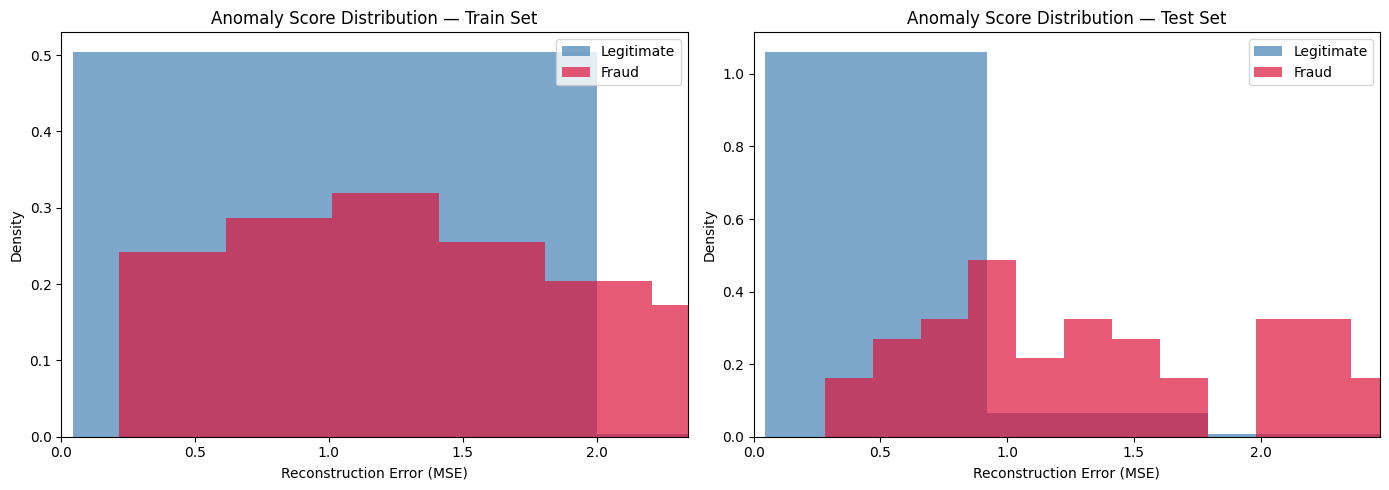

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mse, y_lbl, title in [
    (axes[0], mse_train, y_train_ae, 'Train Set'),
    (axes[1], mse_test,  y_test_ae,  'Test Set')]:
    ax.hist(mse[y_lbl==0], bins=100, alpha=0.7, color='steelblue', label='Legitimate', density=True)
    ax.hist(mse[y_lbl==1], bins=100, alpha=0.7, color='crimson',   label='Fraud',      density=True)
    ax.set_title(f'Anomaly Score Distribution — {title}', fontsize=12)
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(0, np.percentile(mse, 99))
plt.tight_layout()
plt.savefig('anomaly_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.10 Feature Engineering — Append Anomaly Score

In [36]:
# ==========================================================
# COMBINE ORIGINAL + LATENT + ANOMALY FEATURES
# ==========================================================

X_train_combined = np.hstack([
    X_train_scaled_ae,
    X_train_encoded,
    mse_train.reshape(-1, 1)
])

X_test_combined = np.hstack([
    X_test_scaled_ae,
    X_test_encoded,
    mse_test.reshape(-1, 1)
])

print('Combined Feature Shape:', X_train_combined.shape)

# ==========================================================
# SMOTE BALANCING
# ==========================================================

smote_hybrid = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote_hybrid.fit_resample(
    X_train_combined,
    y_train_ae
)

print('\nSMOTE balancing completed.')
print('Balanced shape:', X_train_resampled.shape)


Feature space expanded: 30 -> 31 features
New feature: anomaly_score (Autoencoder reconstruction error)
X_train_ae_rf shape: (227845, 31)
X_test_ae_rf shape:  (56962, 31)


### 2.11 SMOTE on Augmented Training Set

In [37]:
smote_hybrid = SMOTE(sampling_strategy='auto', random_state=42)
X_train_ae_rf_resampled, y_train_resampled = smote_hybrid.fit_resample(
    X_train_ae_rf, y_train_ae)
print(f'Before SMOTE: {dict(y_train_ae.value_counts())}')
print(f'After SMOTE:  {dict(pd.Series(y_train_resampled).value_counts())}')
print(f'Resampled shape: {X_train_ae_rf_resampled.shape}')

Before SMOTE: {0: np.int64(227451), 1: np.int64(394)}
After SMOTE:  {0: np.int64(227451), 1: np.int64(227451)}
Resampled shape: (454902, 31)


### 2.12 Train Random Forest Classifier

In [38]:
print('Training Optimized Random Forest Hybrid...')

start = time.time()

rf_hybrid = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_hybrid.fit(X_train_resampled, y_train_resampled)

elapsed = time.time() - start

print(f'\nTraining completed in {elapsed:.2f} seconds')


Training Random Forest on anomaly-enriched feature set...
Training complete in 735.2 seconds.
Trees: 200 | Features: 31


---
## Section 3 — Model Evaluation & Visualisation

### 3.1 Predictions & Classification Report

In [39]:
# ==========================================================
# HYBRID MODEL EVALUATION
# ==========================================================

probs_hybrid = rf_hybrid.predict_proba(X_test_combined)[:, 1]

# ==========================================================
# THRESHOLD OPTIMIZATION
# ==========================================================

best_f1 = 0
best_threshold = 0.5

for th in np.arange(0.10, 0.91, 0.02):

    preds_temp = (probs_hybrid > th).astype(int)

    score = f1_score(y_test_ae, preds_temp)

    if score > best_f1:
        best_f1 = score
        best_threshold = th

print(f'Best Threshold: {best_threshold:.2f}')
print(f'Best F1 Score : {best_f1:.4f}')

# Final predictions
preds_hybrid = (probs_hybrid > best_threshold).astype(int)

# Metrics
f1_val  = f1_score(y_test_ae, preds_hybrid)
auc_val = roc_auc_score(y_test_ae, probs_hybrid)
ap_val  = average_precision_score(y_test_ae, probs_hybrid)

print('=' * 60)
print('     IMPROVED HYBRID MODEL RESULTS')
print('=' * 60)

print('\nClassification Report:\n')

print(classification_report(
    y_test_ae,
    preds_hybrid,
    digits=4
))

print(f'ROC-AUC Score        : {auc_val:.4f}')
print(f'Average Precision    : {ap_val:.4f}')
print(f'Optimized F1-Score   : {f1_val:.4f}')


   HYBRID MODEL (Autoencoder + Random Forest) REPORT
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9997    0.9997     56864
       Fraud     0.8367    0.8367    0.8367        98

    accuracy                         0.9994     56962
   macro avg     0.9182    0.9182    0.9182     56962
weighted avg     0.9994    0.9994    0.9994     56962

ROC AUC Score:          0.9676
F1 Score (Fraud):       0.8367
Average Precision (AP): 0.8689


### 3.2 Confusion Matrix

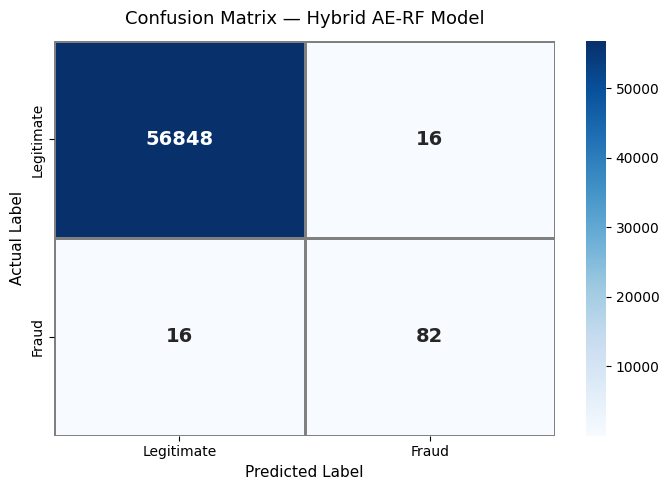

TN: 56,848 | FP: 16 | FN: 16 | TP: 82
Fraud detection rate: 83.7%
False alarm rate:     0.0281%


In [40]:
cm = confusion_matrix(y_test_ae, preds_hybrid)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            linewidths=1, linecolor='gray',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — Hybrid AE-RF Model', fontsize=13, pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix_ae_rf.png', dpi=150, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}')
print(f'Fraud detection rate: {tp/(tp+fn)*100:.1f}%')
print(f'False alarm rate:     {fp/(fp+tn)*100:.4f}%')

### 3.3 ROC Curve

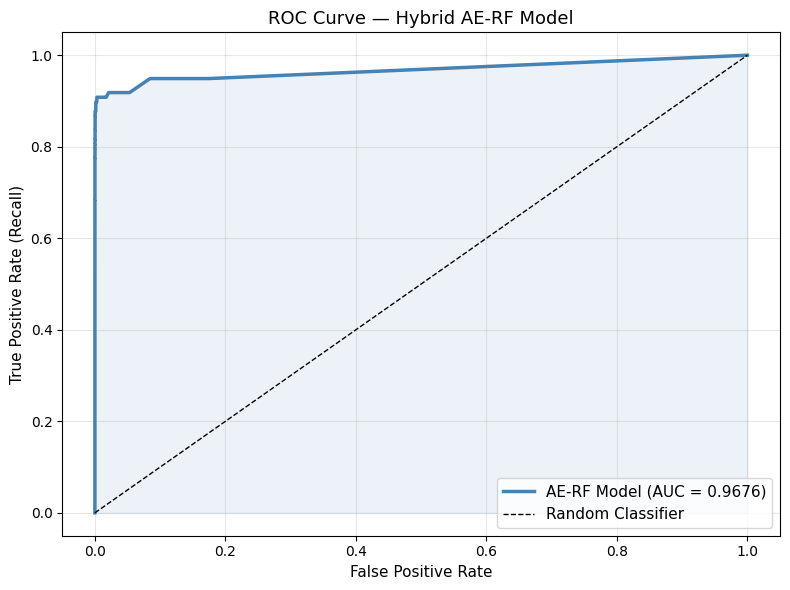

In [41]:
fpr, tpr, _ = roc_curve(y_test_ae, probs_hybrid)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'AE-RF Model (AUC = {auc_val:.4f})')
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.title('ROC Curve — Hybrid AE-RF Model', fontsize=13)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_ae_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Precision-Recall Curve

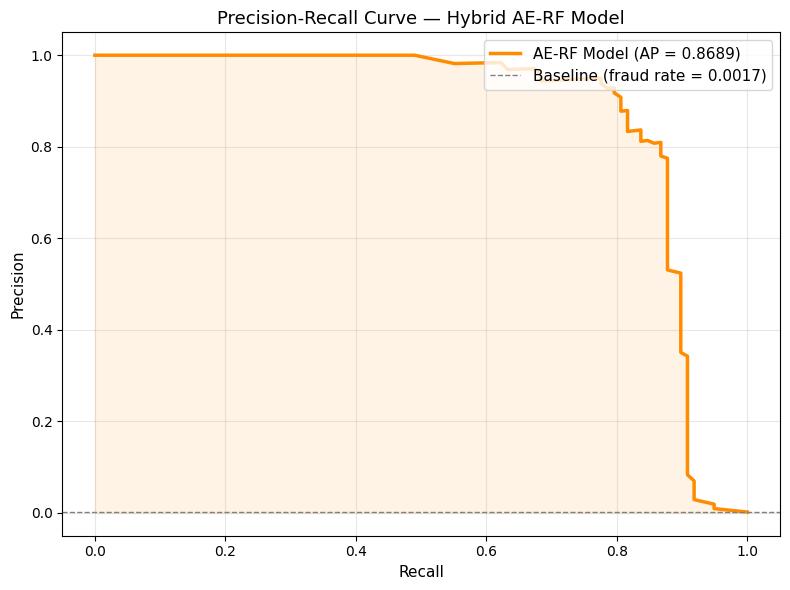

In [42]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test_ae, probs_hybrid)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='darkorange', linewidth=2.5,
         label=f'AE-RF Model (AP = {ap_val:.4f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color='darkorange')
plt.axhline(y=y_test_ae.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Baseline (fraud rate = {y_test_ae.mean():.4f})')
plt.title('Precision-Recall Curve — Hybrid AE-RF Model', fontsize=13)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve_ae_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Feature Importance — Top 20 Features
> The **anomaly_score** feature (highlighted in red) is the reconstruction error from the Autoencoder — a novel engineered feature not present in the group's models.

Top 20 Most Important Features:
      Feature  Importance
          V14    0.197551
          V10    0.164503
anomaly_score    0.098506
           V4    0.093469
          V12    0.079000
          V17    0.071787
           V3    0.054275
          V11    0.052963
          V16    0.029566
           V7    0.026557
           V2    0.017023
           V9    0.014921
          V21    0.009038
           V6    0.008613
          V18    0.008388
           V1    0.008019
         Time    0.007654
           V8    0.006430
          V13    0.005470
          V20    0.004796


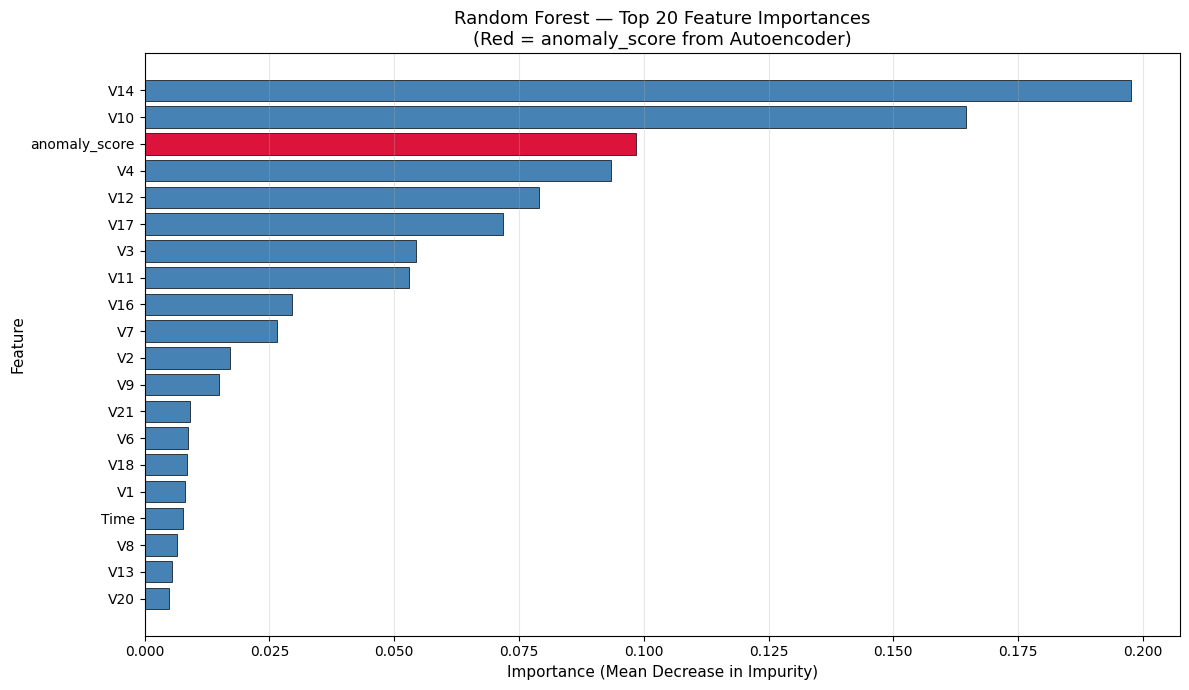


anomaly_score rank: #3 out of 31 features
anomaly_score importance: 0.098506


In [43]:
feature_names = list(X_test_ae_rf.columns)
importances   = rf_hybrid.feature_importances_

feat_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 20 Most Important Features:')
print(feat_df.head(20).to_string(index=False))

top20  = feat_df.head(20)
colors = ['crimson' if f == 'anomaly_score' else 'steelblue' for f in top20['Feature']]

plt.figure(figsize=(12, 7))
plt.barh(top20['Feature'][::-1], top20['Importance'][::-1],
         color=colors[::-1], edgecolor='black', linewidth=0.5)
plt.title('Random Forest — Top 20 Feature Importances\n(Red = anomaly_score from Autoencoder)',
          fontsize=13)
plt.xlabel('Importance (Mean Decrease in Impurity)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_ae_rf.png', dpi=150, bbox_inches='tight')
plt.show()

anomaly_rank = feat_df[feat_df['Feature'] == 'anomaly_score'].index[0] + 1
anomaly_imp  = feat_df[feat_df['Feature'] == 'anomaly_score']['Importance'].values[0]
print(f'\nanomaly_score rank: #{anomaly_rank} out of {len(feat_df)} features')
print(f'anomaly_score importance: {anomaly_imp:.6f}')

### 3.6 Full Evaluation Dashboard

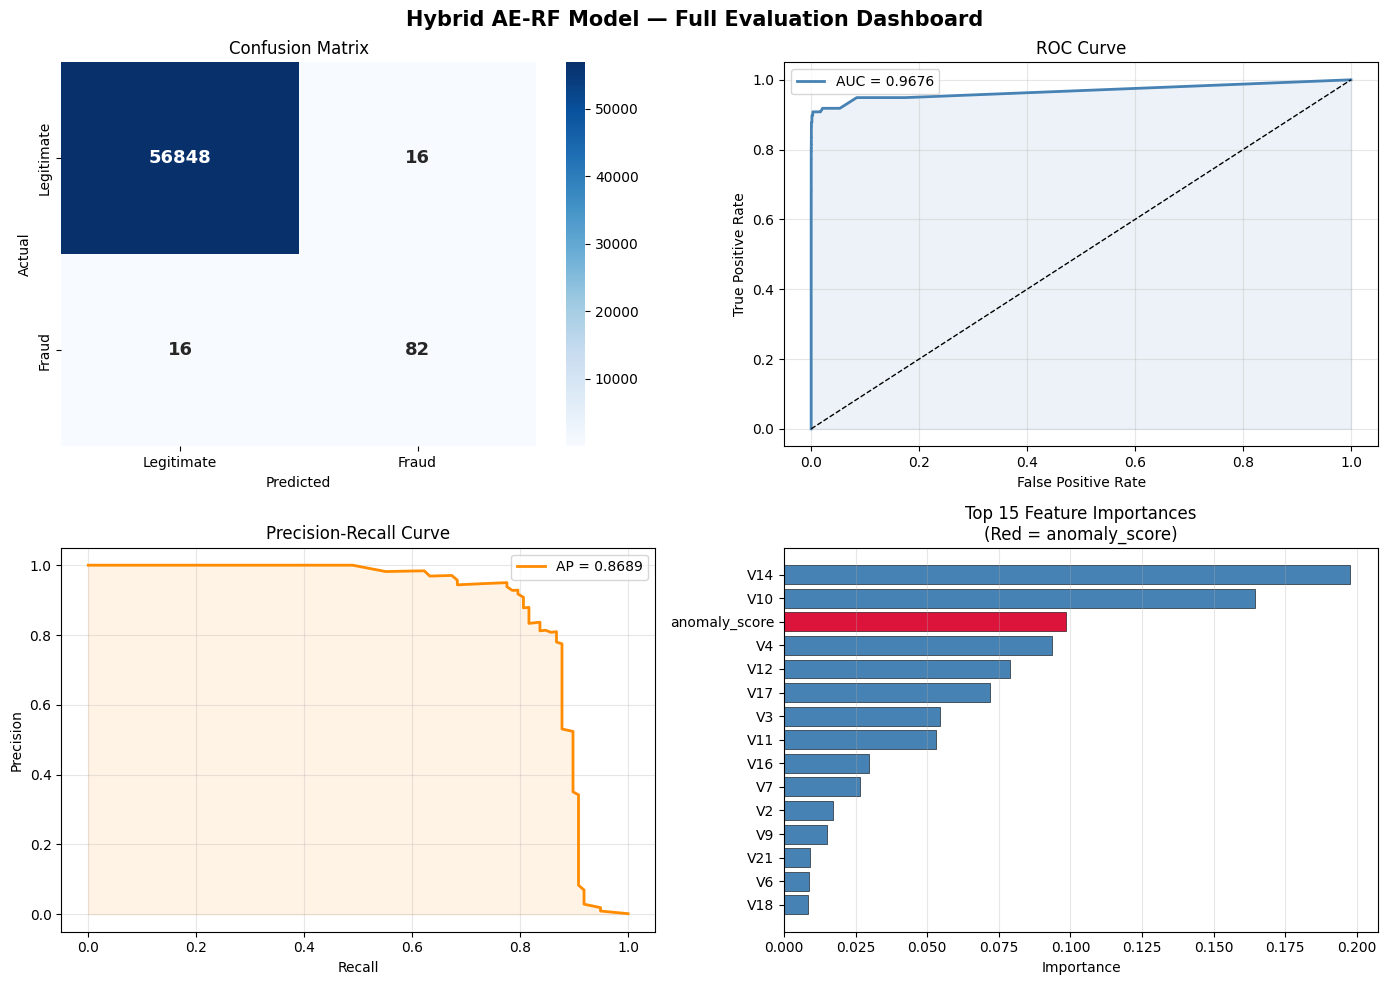

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hybrid AE-RF Model — Full Evaluation Dashboard', fontsize=15, fontweight='bold')

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'],
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0,0].set_title('Confusion Matrix', fontsize=12)
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
axes[0,1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_val:.4f}')
axes[0,1].plot([0,1],[0,1],'k--', linewidth=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0,1].set_title('ROC Curve', fontsize=12)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(fontsize=10)
axes[0,1].grid(True, alpha=0.3)

# PR Curve
axes[1,0].plot(recall_vals, precision_vals, color='darkorange', linewidth=2, label=f'AP = {ap_val:.4f}')
axes[1,0].fill_between(recall_vals, precision_vals, alpha=0.1, color='darkorange')
axes[1,0].set_title('Precision-Recall Curve', fontsize=12)
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# Feature Importance Top 15
top15    = feat_df.head(15)
colors15 = ['crimson' if f == 'anomaly_score' else 'steelblue' for f in top15['Feature']]
axes[1,1].barh(top15['Feature'][::-1], top15['Importance'][::-1],
               color=colors15[::-1], edgecolor='black', linewidth=0.4)
axes[1,1].set_title('Top 15 Feature Importances\n(Red = anomaly_score)', fontsize=12)
axes[1,1].set_xlabel('Importance')
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_dashboard_ae_rf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Final Results Summary

In [45]:
print('=' * 55)
print('   HYBRID AE-RF MODEL — FINAL RESULTS SUMMARY')
print('=' * 55)

tn, fp, fn, tp = cm.ravel()
precision_fraud = tp / (tp + fp)
recall_fraud    = tp / (tp + fn)
f1_fraud        = 2 * precision_fraud * recall_fraud / (precision_fraud + recall_fraud)
accuracy        = (tn + tp) / (tn + fp + fn + tp)

results = {
    'Metric': ['Accuracy', 'Precision (Fraud)', 'Recall (Fraud)',
               'F1-Score (Fraud)', 'ROC AUC', 'Avg Precision (AP)',
               'True Positives', 'False Positives', 'False Negatives', 'True Negatives'],
    'Value':  [f'{accuracy:.4f}', f'{precision_fraud:.4f}', f'{recall_fraud:.4f}',
               f'{f1_fraud:.4f}', f'{auc_val:.4f}', f'{ap_val:.4f}',
               str(tp), str(fp), str(fn), str(tn)]
}

print(pd.DataFrame(results).to_string(index=False))
print(f'\nanomaly_score rank: #{anomaly_rank} / {len(feat_df)} features')

   HYBRID AE-RF MODEL — FINAL RESULTS SUMMARY
            Metric  Value
          Accuracy 0.9994
 Precision (Fraud) 0.8367
    Recall (Fraud) 0.8367
  F1-Score (Fraud) 0.8367
           ROC AUC 0.9676
Avg Precision (AP) 0.8689
    True Positives     82
   False Positives     16
   False Negatives     16
    True Negatives  56848

anomaly_score rank: #3 / 31 features
